# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()


Số dòng: 891 | Số cột: 15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [5]:
# TODO
missing = df.isnull().sum()
if missing.sum()>0 :
   print(missing[missing>0])
else :
    print("không có missing value") 

print("số row lặp là :",df.duplicated().sum())

print(df[df.duplicated(subset = ['age'],keep=False)][['survived','sex','age','fare']].sort_values('age').head(10))


age            177
embarked         2
deck           688
embark_town      2
dtype: int64
số row lặp là : 107
     survived     sex   age     fare
469         1  female  0.75  19.2583
644         1  female  0.75  19.2583
78          1    male  0.83  29.0000
831         1    male  0.83  18.7500
183         1    male  1.00  39.0000
172         1  female  1.00  11.1333
164         0    male  1.00  39.6875
827         1    male  1.00  37.0042
381         1  female  1.00  15.7417
386         0    male  1.00  46.9000


## A.3. Invalid values

In [ ]:
# TODO
print("age <= 0:", (df['age']<=0).sum())
print("survived ngoài [0,1]:", ((df['survived']<0)|(df['survived']>1)).sum())


age <= 0: 0
survived ngoài [0,1]: 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [6]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] +1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# TODO
for col in ['fare','age']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()

fare: Mean=32.20, Median=14.45, Mode=8.05
age: Mean=29.70, Median=28.00, Mode=24.00



## Group 2 — Dispersion

In [ ]:
# TODO
for col in ['fare','age']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1 #25-75%
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54
--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=nan, Kurtosis=nan
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


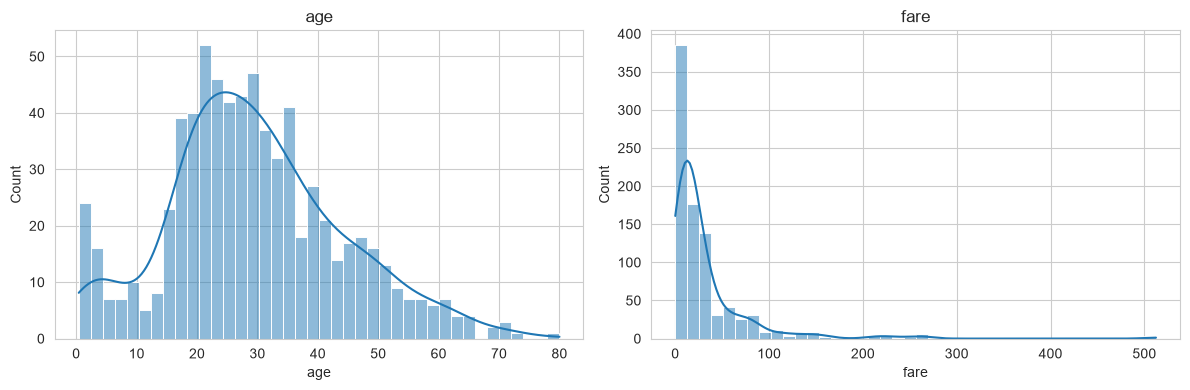

Nhận xét: Age phần lớn từ 20-35 tuổi, giá vé rẻ chiếm tỉ trọng lớn??


In [ ]:
# TODO
for col in ['age','fare']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('fare')
plt.tight_layout(); plt.show()

print("Nhận xét: Age phần lớn từ 20-35 tuổi, giá vé rẻ chiếm tỉ trọng lớn??")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


In [15]:
# TODO
survival_rate = df.groupby('pclass')['survived'].mean().sort_values()
print(survival_rate)
print(f"vé có tỉ lệ sống cao nhất là hạng {survival_rate.index[-1]}, {survival_rate.iloc[-1]*100:2.2f}% \n")
print(f"vé có tỉ lệ sống thấp nhất là hạng {survival_rate.index[0]}, {survival_rate.iloc[0]*100:2.2f}% \n")
print(f"chênh lệch range = {(survival_rate.max()-survival_rate.min())*100:2.2f}% ")


pclass
3    0.242363
2    0.472826
1    0.629630
Name: survived, dtype: float64
vé có tỉ lệ sống cao nhất là hạng 1, 62.96% 

vé có tỉ lệ sống thấp nhất là hạng 3, 24.24% 

chênh lệch range = 38.73% 


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [ ]:
# TODO


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

nhận xét : vé giá cao có ảnh hưởng đến tỉ lệ sống nhưng bảo hòa khi giá >150


C:\Users\Vu\AppData\Local\Temp\ipykernel_12076\384600686.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate, x='fare_groups', y='survived', palette='Blues_d')


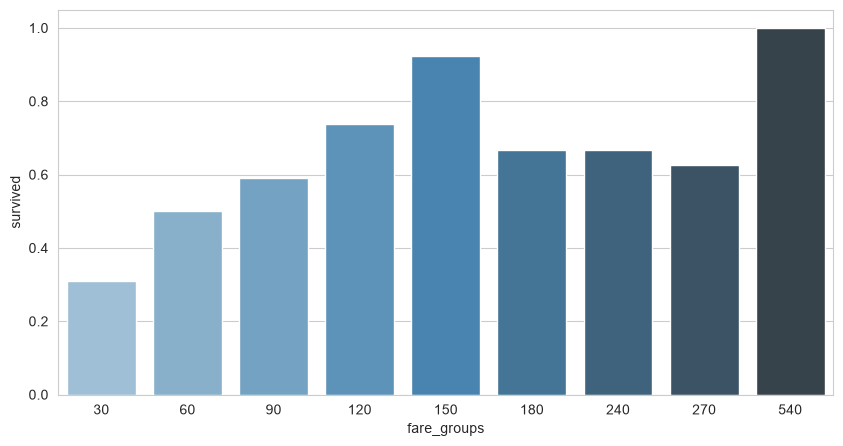

In [ ]:
# TODO
groups = []
for fare in df['fare'] :
   group = min(int(fare // 30 + 1) * 30, 1000) # nhóm fare thành các nhóm cách nhau 30
   groups.append(group)

df['fare_groups']  = groups
survival_rate = df.groupby('fare_groups')['survived'].mean().sort_index().reset_index()
survival_rate
    

plt.figure(figsize=(9, 5))
sns.barplot(data=survival_rate, x='fare_groups', y='survived', palette='Blues_d')

print("nhận xét : vé giá cao có ảnh hưởng đến tỉ lệ sống nhưng bảo hòa khi giá >150")

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,fare_grop,fare_groups
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0-50,30
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,50-100,90
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,0-50,30
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,50-100,60
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,0-50,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1,0-50,30
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1,0-50,60
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4,0-50,30
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1,0-50,60


C:\Users\Vu\AppData\Local\Temp\ipykernel_12076\3240109289.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=far, x='family_size', y='survived', palette='Blues_d')


<Axes: xlabel='family_size', ylabel='survived'>

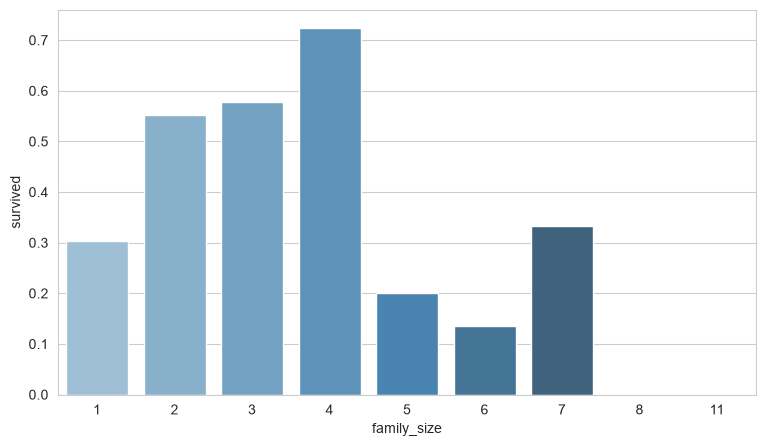

In [ ]:
# TODO
far = df.groupby('family_size')['survived'].mean().sort_index().reset_index()
far
plt.figure(figsize=(9, 5))
sns.barplot(data=far, x='family_size', y='survived', palette='Blues_d')

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [ ]:
# TODO


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*(Viết insight của bạn vào đây...)*